# Problema 3. Identificacion de estados ocultos de degradacion en motores aeronauticos

Dato de entrada: NASA CMAPSS, series multivariantes por motor con ajustes operacionales y ruido de sensores.

Estado latente: nivel de salud del motor, no observable directamente.

Modelo: HMM con emisiones gaussianas y transicion predominantemente progresiva, ajustado con Baum-Welch.

Salida verificable: trayectorias de estado por motor, matriz de transicion, duracion media de cada estado y ciclos de anticipacion de la primera alerta severa.

---

## Como leer este cuaderno

Cada bloque de codigo va precedido por una celda que explica que hace y con que idea del capitulo 3 de Duda, Hart y Stork (*Pattern Classification*, 2.ª ed.) se conecta, y las salidas importantes van seguidas de una celda de lectura con los numeros y las figuras reales.

El problema es el primero de la serie que usa variables no observadas en el tiempo. Un motor pasa por estados de salud que nadie mide directamente; lo que se mide son 21 sensores en cada ciclo de vuelo. El modelo oculto de Markov (seccion 3.10 del capitulo) formaliza exactamente esa situacion: una cadena de estados $Z_t$ que evoluciona con una matriz de transicion, y observaciones $X_t$ cuya distribucion depende del estado. Las tres preguntas clasicas del capitulo aparecen todas: evaluar la probabilidad de una secuencia (forward), decodificar la secuencia de estados mas probable (Viterbi) y aprender los parametros a partir de secuencias sin etiquetas (Baum-Welch, que es EM).

La carpeta `datos/` no contiene los archivos de NASA, asi que el cuaderno corre sobre el sustituto simulado que la propia celda de carga genera: sesenta motores con degradacion progresiva y firma de sensores propia. Todos los numeros de este cuaderno se refieren a ese sustituto y sirven para validar el metodo; con los archivos reales en `datos/` el codigo corre sin cambios.

## Mapa entre el cuaderno y el capitulo 3

| Seccion del cuaderno | Idea del capitulo | Donde esta en el libro |
|---|---|---|
| Funciones HMM: emisiones gaussianas | Densidad normal multivariante y su evaluacion estable con Cholesky | 3.2.3 y 2.6 |
| Funciones HMM: adelante-atras | Evaluacion de $P(X_{1:T})$ con el algoritmo hacia adelante y calculo de $\gamma_t(j)$ y $\xi_t(i,j)$ | 3.10.3 y 3.10.4 |
| Funciones HMM: Viterbi | Decodificacion: la secuencia de estados mas probable | 3.10.5 |
| Funciones HMM: Baum-Welch | Aprendizaje de $\pi$, $A$ y las emisiones como un caso de EM | 3.10.6 y 3.9 |
| Verificacion con parametros conocidos | Comprobar que el estimador recupera lo que genero los datos antes de usarlo en datos reales | 3.2 (consistencia del MLE) |
| Seleccion del numero de estados | Complejidad del modelo frente a datos disponibles; sobreajuste | 3.7.3 |
| Reinicios de EM | EM converge a un maximo local, no necesariamente al global | 3.9 |
| Diagnostico de supuestos | Markov de primer orden, emisiones gaussianas, independencia entre secuencias | 3.10.1 y 3.1 |

## Notacion

$Z_t \in \{0, \dots, K-1\}$ es el estado oculto en el instante $t$ y $X_t \in \mathbb{R}^d$ el vector observado. $\pi_j = P(Z_1 = j)$ es la distribucion inicial, $a_{ij} = P(Z_t = j \mid Z_{t-1} = i)$ la matriz de transicion $A$, y $b_j(x) = p(x \mid Z_t = j) = \mathcal{N}(x; \mu_j, \Sigma_j)$ la densidad de emision. $\alpha_t(j) = P(X_{1:t}, Z_t = j)$ es la variable hacia adelante, $\beta_t(j) = P(X_{t+1:T} \mid Z_t = j)$ la variable hacia atras, $\gamma_t(j) = P(Z_t = j \mid X_{1:T})$ la probabilidad suavizada de cada estado y $\xi_t(i, j) = P(Z_t = i, Z_{t+1} = j \mid X_{1:T})$ la de cada transicion. El libro llama a $\alpha$ y $\beta$ "forward" y "backward" (seccion 3.10.3) y escribe la matriz de transicion como $a_{ij}$ y la de emision como $b_{jk}$ para observaciones discretas; aqui las observaciones son continuas y $b_j$ es una densidad gaussiana, que es la extension que el propio capitulo menciona al final de la seccion 3.10.

**Que hace esta celda.** Instala `numpy`, `pandas` y `matplotlib`. Todo el HMM (evaluacion, decodificacion y aprendizaje) se programa a mano en las celdas siguientes en lugar de usar una libreria especializada, para que cada paso se pueda leer al lado de la ecuacion del capitulo que lo justifica.

In [1]:
!pip install numpy pandas matplotlib

**Que hace esta celda.** Importa las librerias, fija la semilla `SEED = 7` para que los sorteos (inicializaciones de EM, particiones, datos simulados) sean reproducibles, y configura la presentacion de tablas y figuras.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 7
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## HMM gaussiano

$$P(Z_t = j \mid Z_{t-1} = i) = a_{ij}, \qquad X_t \mid Z_t = j \sim \mathcal{N}_d(\mu_j, \Sigma_j)$$

Forward-backward y Viterbi en escala logaritmica. Baum-Welch es EM sobre esta estructura: el paso E son las responsabilidades $\gamma_t(j)$ y $\xi_t(i,j)$ que devuelve forward-backward, el paso M son las frecuencias esperadas de transicion y las medias y covarianzas ponderadas por $\gamma$.

`progresiva=True` enmascara la matriz de transicion a triangular superior, lo que impide regresar a un estado anterior.

**Por que un HMM y no un clasificador.** En los problemas 1 y 2 cada observacion se trataba por separado. Aqui las observaciones de un motor son una secuencia, y el estado de salud en un ciclo depende del estado en el ciclo anterior: un motor que ya esta degradado no vuelve a estar sano. La seccion 3.10.1 introduce precisamente los procesos de Markov de primer orden para capturar esa dependencia, y la 3.10.2 los modelos ocultos, donde el estado no se ve y solo se observan sus efectos. La restriccion progresiva es una manera de escribir en la matriz $A$ el conocimiento de ingenieria de que la degradacion no se revierte sola.

**Que hace esta celda.** Define las funciones numericas basicas sobre las que se construye el HMM.

`logsumexp(a)` calcula $\log \sum_k e^{a_k}$ sin desbordar: resta el maximo antes de exponenciar y lo vuelve a sumar despues. Es la operacion que permite trabajar con probabilidades en escala logaritmica, algo imprescindible aqui porque la probabilidad de una secuencia de cientos de observaciones es un numero del orden de $10^{-500}$, que en coma flotante es simplemente cero. El capitulo lo advierte en la seccion 3.10.3: los productos de probabilidades en el algoritmo hacia adelante se hacen minusculos y hay que reescalar.

`familia_covarianza(S, tipo, lam)` devuelve la version de la covarianza que se quiere usar: completa, diagonal, esferica (un solo numero por la identidad) o contraida hacia la diagonal. Es la misma idea de la seccion 3.7.3: restringir la covarianza para reducir el numero de parametros cuando los datos no alcanzan para estimarla completa.

`cholesky_segura(S)` factoriza $S = LL^\top$; si $S$ no es definida positiva, agrega a la diagonal una cantidad creciente hasta lograrlo, y como ultimo recurso se queda con la diagonal. Evita que un EM se caiga por una covarianza degenerada en una iteracion intermedia.

`log_normal(X, mu, S)` y `log_normal_L(X, mu, L)` evaluan $\log \mathcal{N}(x; \mu, \Sigma)$ para todas las filas de `X`. La distancia de Mahalanobis se obtiene resolviendo el sistema triangular $La = x - \mu$ y sumando $a^\top a$, y el log determinante es $2\sum \log L_{ii}$. Es la densidad de la seccion 3.2.3 calculada sin invertir $\Sigma$, como recomienda la seccion 3.7.2.

`factorizar` y `log_emisiones` calculan una sola vez por iteracion el factor de Cholesky de cada estado y devuelven la matriz $T \times K$ con $\log b_j(x_t)$ para cada instante y cada estado. Esa matriz es la entrada de todos los algoritmos siguientes.

In [3]:
def logsumexp(a, axis=None):
    a = np.asarray(a, dtype=float)
    m = np.max(a, axis=axis, keepdims=True)
    m = np.where(np.isfinite(m), m, 0.0)
    s = m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))
    return np.squeeze(s, axis=axis) if axis is not None else float(s.ravel()[0])


def familia_covarianza(S, tipo="diagonal", lam=0.0):
    d = S.shape[0]
    if tipo == "completa":
        return S.copy()
    if tipo == "diagonal":
        return np.diag(np.diag(S))
    if tipo == "esferica":
        return (np.trace(S) / d) * np.eye(d)
    if tipo == "contraida":
        return (1.0 - lam) * S + lam * np.diag(np.diag(S))
    raise ValueError(tipo)


def cholesky_segura(S, jitter=1e-8, intentos=14):
    d = S.shape[0]
    for k in range(intentos):
        try:
            return np.linalg.cholesky(S + (jitter * 10.0 ** k) * np.eye(d))
        except np.linalg.LinAlgError:
            continue
    return np.linalg.cholesky(np.diag(np.maximum(np.diag(S), 1e-6)))


def log_normal(X, mu, S):
    d = len(mu)
    L = cholesky_segura(S)
    A = np.linalg.solve(L, (X - mu).T)
    maha = np.sum(A ** 2, axis=0)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + maha)


def factorizar(Sigmas):
    """Cholesky de cada covarianza, una sola vez por iteracion de EM."""
    return [cholesky_segura(S) for S in Sigmas]


def log_normal_L(X, mu, L):
    d = len(mu)
    A = np.linalg.solve(L, (X - mu).T)
    return -0.5 * (d * np.log(2.0 * np.pi) + 2.0 * np.sum(np.log(np.diag(L)))
                   + np.sum(A ** 2, axis=0))


def log_emisiones(X, mus, Sigmas, Ls=None):
    Ls = factorizar(Sigmas) if Ls is None else Ls
    return np.column_stack([log_normal_L(X, mus[j], Ls[j]) for j in range(len(mus))])

**Que hace esta celda.** Implementa los tres algoritmos de inferencia del HMM, todos en escala logaritmica.

`adelante_atras(log_b, log_pi, log_A)` es el algoritmo forward-backward de la seccion 3.10.3.

- La recursion hacia adelante empieza con $\alpha_1(j) = \pi_j b_j(x_1)$ y avanza con $\alpha_t(j) = b_j(x_t)\sum_i \alpha_{t-1}(i)\,a_{ij}$. En el codigo, `m = log_alfa[t-1][:, None] + log_A` forma la matriz $\log(\alpha_{t-1}(i)\,a_{ij})$ y la suma sobre $i$ se hace con el truco del maximo.
- La recursion hacia atras empieza con $\beta_T(j) = 1$ y retrocede con $\beta_t(i) = \sum_j a_{ij}\,b_j(x_{t+1})\,\beta_{t+1}(j)$.
- La log verosimilitud de la secuencia es $\log P(X_{1:T}) = \log\sum_j \alpha_T(j)$; es el problema de evaluacion de la seccion 3.10.4.
- $\gamma_t(j) = \alpha_t(j)\beta_t(j) / P(X_{1:T})$ es la probabilidad de estar en el estado $j$ en el instante $t$ dada toda la secuencia, y $\xi_t(i,j) = \alpha_t(i)\,a_{ij}\,b_j(x_{t+1})\,\beta_{t+1}(j) / P(X_{1:T})$ la de la transicion $i \to j$. La funcion devuelve $\gamma$ completo y $\xi$ ya sumado sobre $t$, que es lo unico que necesita el paso M.

`viterbi(log_b, log_pi, log_A)` resuelve el problema de decodificacion de la seccion 3.10.5: encuentra la secuencia de estados de maxima probabilidad conjunta. Es la misma recursion que la hacia adelante pero reemplazando la suma sobre $i$ por un maximo, guardando en `psi` que estado dio ese maximo, y recorriendo `psi` hacia atras desde el final para reconstruir el camino. El libro lo presenta como la busqueda del camino de mayor probabilidad en la rejilla de estados por tiempo.

`filtrar(log_b, log_pi, log_A)` es solo la mitad hacia adelante, normalizada en cada instante: devuelve $P(Z_t = j \mid X_{1:t})$, la probabilidad de cada estado usando unicamente el pasado. Es la version que se puede calcular en tiempo real, cuando el futuro todavia no se ha observado, y es la que se usa para las alertas.

In [4]:
def adelante_atras(log_b, log_pi, log_A):
    T, K = log_b.shape
    log_alfa = np.empty((T, K))
    log_beta = np.zeros((T, K))

    log_alfa[0] = log_pi + log_b[0]
    for t in range(1, T):
        m = log_alfa[t - 1][:, None] + log_A
        pico = m.max(axis=0)
        log_alfa[t] = log_b[t] + pico + np.log(np.exp(m - pico).sum(axis=0))

    for t in range(T - 2, -1, -1):
        m = log_A + (log_b[t + 1] + log_beta[t + 1])
        pico = m.max(axis=1)
        log_beta[t] = pico + np.log(np.exp(m - pico[:, None]).sum(axis=1))

    loglik = logsumexp(log_alfa[-1])
    gamma = np.exp(log_alfa + log_beta - loglik)

    M = (log_alfa[:-1, :, None] + log_A[None, :, :]
         + (log_b[1:] + log_beta[1:])[:, None, :] - loglik)
    xi = np.exp(M).sum(axis=0)
    return gamma, xi, float(loglik)


def viterbi(log_b, log_pi, log_A):
    T, K = log_b.shape
    delta = np.empty((T, K))
    psi = np.zeros((T, K), dtype=int)
    delta[0] = log_pi + log_b[0]
    for t in range(1, T):
        m = delta[t - 1][:, None] + log_A
        psi[t] = np.argmax(m, axis=0)
        delta[t] = np.max(m, axis=0) + log_b[t]
    camino = np.empty(T, dtype=int)
    camino[-1] = int(np.argmax(delta[-1]))
    for t in range(T - 2, -1, -1):
        camino[t] = psi[t + 1, camino[t + 1]]
    return camino, float(np.max(delta[-1]))


def filtrar(log_b, log_pi, log_A):
    T, K = log_b.shape
    log_alfa = np.empty((T, K))
    log_alfa[0] = log_pi + log_b[0]
    for t in range(1, T):
        m = log_alfa[t - 1][:, None] + log_A
        pico = m.max(axis=0)
        log_alfa[t] = log_b[t] + pico + np.log(np.exp(m - pico).sum(axis=0))
    return np.exp(log_alfa - logsumexp(log_alfa, axis=1)[:, None])

**Que hace esta celda.** Implementa el aprendizaje del HMM: Baum-Welch, que el capitulo presenta en la seccion 3.10.6 como el algoritmo forward-backward de aprendizaje y que es un caso particular del EM de la seccion 3.9, donde la variable no observada es la secuencia de estados.

`iniciar(...)` construye un punto de partida. Elige $K$ observaciones al azar como centros, asigna cada observacion al centro mas cercano (un paso de k-medias) y con esa asignacion calcula medias y covarianzas iniciales. La matriz $A$ inicial tiene la diagonal muy pesada (los estados tienden a persistir) y, si `progresiva = True`, se enmascara a triangular superior y la distribucion inicial concentra la probabilidad en el estado 0, de modo que la cadena solo puede avanzar hacia estados de indice mayor.

`baum_welch(...)` alterna dos pasos hasta que la log verosimilitud deja de crecer:

*Paso E.* Para cada secuencia, calcula las emisiones y corre `adelante_atras`. Acumula cuatro cosas: $\gamma_1$ (para $\pi$), $\sum_t \xi_t$ (para $A$), $\sum_t \gamma_t(j)$ (los "conteos" de cada estado), $\sum_t \gamma_t(j)\,x_t$ y $\sum_t \gamma_t(j)\,x_t x_t^\top$ (para las emisiones). Estas sumas son las estadisticas suficientes esperadas del capitulo 3.9: la funcion $Q(\theta; \theta^i)$ solo depende de ellas.

*Paso M.* Cada parametro se actualiza con las formulas de la seccion 3.10.6: $\hat\pi_j$ es la probabilidad de empezar en $j$, $\hat a_{ij}$ es el numero esperado de transiciones $i \to j$ dividido por el numero esperado de salidas desde $i$, y $\hat\mu_j$, $\hat\Sigma_j$ son la media y la covarianza de las observaciones ponderadas por $\gamma_t(j)$. Son los MLE de la seccion 3.2 con pesos en lugar de asignaciones duras. La mascara `mascara` aplica la restriccion progresiva a cada iteracion, y `piso` suma una cantidad minima a la diagonal de cada covarianza para que ningun estado colapse sobre una sola observacion.

*Parada.* Cuando el incremento relativo de la log verosimilitud baja de `tol`.

`ajustar_hmm(...)` corre Baum-Welch varias veces con semillas distintas y se queda con la corrida de mayor log verosimilitud. Es la respuesta practica a la advertencia de la seccion 3.9: EM garantiza que la verosimilitud no baja, pero no que llegue al maximo global, y desde inicializaciones distintas puede terminar en optimos locales distintos.

In [5]:
def iniciar(secuencias, K, rng, tipo, lam, progresiva):
    X = np.vstack(secuencias)
    n, d = X.shape
    centros = X[rng.choice(n, size=K, replace=False)]
    etiqueta = np.argmin(((X[:, None, :] - centros[None]) ** 2).sum(axis=2), axis=1)

    S_global = np.cov(X, rowvar=False, ddof=1) + 1e-6 * np.eye(d)
    mus, Sigmas = [], []
    for j in range(K):
        sel = etiqueta == j
        if sel.sum() > d + 1:
            mus.append(X[sel].mean(axis=0))
            Sigmas.append(familia_covarianza(np.cov(X[sel], rowvar=False, ddof=1), tipo, lam))
        else:
            mus.append(centros[j])
            Sigmas.append(familia_covarianza(S_global, tipo, lam))

    if progresiva:
        A = np.triu(rng.uniform(0.05, 0.30, size=(K, K)))
        np.fill_diagonal(A, rng.uniform(3.0, 10.0, size=K))
        pi = np.full(K, 1e-3)
        pi[0] = 1.0
    else:
        A = rng.uniform(0.05, 0.30, size=(K, K))
        np.fill_diagonal(A, rng.uniform(2.0, 8.0, size=K))
        pi = rng.uniform(0.5, 1.5, size=K)

    A = A / A.sum(axis=1, keepdims=True)
    pi = pi / pi.sum()
    return pi, A, np.array(mus), np.array(Sigmas)


def baum_welch(secuencias, K, iteraciones=200, tol=1e-7, semilla=0,
               tipo="diagonal", lam=0.0, progresiva=False, piso=1e-6):
    rng = np.random.default_rng(semilla)
    secuencias = [np.asarray(s, dtype=float) for s in secuencias]
    d = secuencias[0].shape[1]

    pi, A, mus, Sigmas = iniciar(secuencias, K, rng, tipo, lam, progresiva)
    mascara = np.triu(np.ones((K, K))) if progresiva else np.ones((K, K))

    historia = []
    for it in range(iteraciones):
        log_pi, log_A = np.log(pi + 1e-300), np.log(A + 1e-300)
        Ls = factorizar(Sigmas)
        acum_pi = np.zeros(K)
        acum_xi = np.zeros((K, K))
        acum_g = np.zeros(K)
        acum_gx = np.zeros((K, d))
        acum_gxx = np.zeros((K, d, d))
        loglik = 0.0

        for X in secuencias:
            log_b = log_emisiones(X, mus, Sigmas, Ls)
            gamma, xi, ll = adelante_atras(log_b, log_pi, log_A)
            loglik += ll
            acum_pi += gamma[0]
            acum_xi += xi
            acum_g += gamma.sum(axis=0)
            acum_gx += gamma.T @ X
            for j in range(K):
                acum_gxx[j] += (X * gamma[:, [j]]).T @ X

        historia.append(loglik)
        pi = acum_pi / acum_pi.sum()
        A = (acum_xi * mascara) + 1e-300
        A = A / A.sum(axis=1, keepdims=True)

        for j in range(K):
            peso = max(acum_g[j], 1e-12)
            mu_j = acum_gx[j] / peso
            S_j = acum_gxx[j] / peso - np.outer(mu_j, mu_j)
            S_j = 0.5 * (S_j + S_j.T) + piso * np.eye(d)
            mus[j] = mu_j
            Sigmas[j] = familia_covarianza(S_j, tipo, lam)

        if it > 0 and abs(historia[-1] - historia[-2]) < tol * abs(historia[-2]):
            break

    return {"pi": pi, "A": A, "mus": mus, "Sigmas": Sigmas, "loglik": historia[-1],
            "historia": historia, "K": K, "d": d, "tipo": tipo, "lam": lam,
            "progresiva": progresiva, "iteraciones": len(historia)}


def ajustar_hmm(secuencias, K, reinicios=5, semilla=0, **kw):
    corridas = [baum_welch(secuencias, K, semilla=semilla + 1000 * r, **kw)
                for r in range(reinicios)]
    mejor = max(corridas, key=lambda m: m["loglik"])
    mejor["corridas"] = corridas
    mejor["reinicios"] = pd.DataFrame([{"semilla": semilla + 1000 * r,
                                        "loglik": c["loglik"],
                                        "iteraciones": c["iteraciones"]}
                                       for r, c in enumerate(corridas)])
    return mejor

**Que hace esta celda.** Utilidades que se usan en el resto del cuaderno.

`log_verosimilitud(modelo, secuencias)` suma $\log P(X_{1:T})$ sobre un conjunto de secuencias con los parametros del modelo. Es la medida de ajuste, y evaluada sobre secuencias no usadas en el entrenamiento es la medida de generalizacion.

`estados(modelo, X, modo)` devuelve, para una secuencia, la ruta de Viterbi, las probabilidades filtradas (solo pasado) o las suavizadas $\gamma_t$ (toda la secuencia), segun `modo`.

`duracion_media(A)` calcula $1 / (1 - a_{jj})$. En una cadena de Markov de primer orden, el tiempo que se permanece en un estado sigue una distribucion geometrica, y esa es su media. Es una consecuencia directa de la hipotesis de la seccion 3.10.1, y sirve mas adelante como diagnostico.

`estacionaria(A)` obtiene la distribucion estacionaria de la cadena, el autovector de $A^\top$ con autovalor 1: la fraccion de tiempo que la cadena pasaria en cada estado a largo plazo.

`parametros_libres` y `aic_bic` cuentan los parametros del modelo (transiciones, distribucion inicial, medias y covarianzas, segun la familia) y calculan los criterios de informacion $\text{AIC} = -2\ell + 2p$ y $\text{BIC} = -2\ell + p\log n$, que penalizan la verosimilitud por el numero de parametros. Son la formalizacion del compromiso entre ajuste y complejidad de la seccion 3.7.3.

`ordenar_por_media` reetiqueta los estados por la media de una variable. Los estados de un HMM no tienen orden intrinseco: permutar sus etiquetas da exactamente la misma verosimilitud, asi que dos corridas de EM pueden encontrar la misma solucion con nombres distintos. Fijar un criterio de orden es lo que permite comparar corridas.

`emparejar_estados` resuelve el mismo problema cuando existe una verdad conocida: busca la permutacion de etiquetas que maximiza la coincidencia entre estados estimados y reales. Solo tiene sentido en datos simulados.

In [6]:
def log_verosimilitud(modelo, secuencias):
    log_pi = np.log(modelo["pi"] + 1e-300)
    log_A = np.log(modelo["A"] + 1e-300)
    total = 0.0
    for X in secuencias:
        log_b = log_emisiones(np.asarray(X, float), modelo["mus"], modelo["Sigmas"])
        total += adelante_atras(log_b, log_pi, log_A)[2]
    return total


def estados(modelo, X, modo="viterbi"):
    log_b = log_emisiones(np.asarray(X, float), modelo["mus"], modelo["Sigmas"])
    log_pi = np.log(modelo["pi"] + 1e-300)
    log_A = np.log(modelo["A"] + 1e-300)
    if modo == "viterbi":
        return viterbi(log_b, log_pi, log_A)[0]
    if modo == "filtrado":
        return filtrar(log_b, log_pi, log_A)
    if modo == "suavizado":
        return adelante_atras(log_b, log_pi, log_A)[0]
    raise ValueError(modo)


def duracion_media(A):
    return 1.0 / (1.0 - np.clip(np.diag(A), 0.0, 1.0 - 1e-12))


def estacionaria(A):
    valores, vectores = np.linalg.eig(A.T)
    v = np.abs(np.real(vectores[:, np.argmin(np.abs(valores - 1.0))]))
    return v / v.sum()


def parametros_libres(K, d, tipo="diagonal", progresiva=False):
    trans = int(K * (K - 1) / 2) if progresiva else K * (K - 1)
    if tipo == "completa":
        cov = K * d * (d + 1) // 2
    elif tipo == "esferica":
        cov = K
    else:
        cov = K * d
    return trans + (K - 1) + K * d + cov


def aic_bic(loglik, K, d, n_obs, tipo="diagonal", progresiva=False):
    p = parametros_libres(K, d, tipo, progresiva)
    return {"parametros": p, "aic": -2.0 * loglik + 2.0 * p,
            "bic": -2.0 * loglik + p * np.log(n_obs)}


def ordenar_por_media(modelo, columna=0):
    """Los estados de un HMM no tienen orden intrinseco. Se reetiquetan por la
    media de una variable para que la lectura sea comparable entre corridas."""
    orden = np.argsort(modelo["mus"][:, columna])
    inverso = np.argsort(orden)
    m = dict(modelo)
    m["mus"] = modelo["mus"][orden]
    m["Sigmas"] = modelo["Sigmas"][orden]
    m["pi"] = modelo["pi"][orden]
    m["A"] = modelo["A"][np.ix_(orden, orden)]
    m["orden"] = orden
    m["inverso"] = inverso
    return m


def emparejar_estados(z_verdadero, z_estimado, K):
    from itertools import permutations
    mejor, mejor_perm = -1.0, tuple(range(K))
    for perm in permutations(range(K)):
        mapa = np.array(perm)
        acierto = float(np.mean(mapa[z_estimado] == z_verdadero))
        if acierto > mejor:
            mejor, mejor_perm = acierto, perm
    return np.array(mejor_perm), mejor

**Que hace esta celda.** Dos funciones para generar datos de un HMM con parametros conocidos. `simular_parametros` construye medias separadas por `separacion` unidades, covarianzas diagonales aleatorias y una matriz de transicion con diagonal dominante (o progresiva). `simular` recorre la cadena: sortea el estado inicial de $\pi$, luego cada estado siguiente de la fila correspondiente de $A$, y en cada instante genera la observacion de la normal del estado actual. Es la definicion generativa del HMM de la seccion 3.10.2 escrita como programa, y sirve para el paso de verificacion que sigue.

In [7]:
def simular_parametros(K, d, semilla=0, separacion=3.0, progresiva=False):
    rng = np.random.default_rng(semilla)
    mus = np.array([separacion * j * np.ones(d) + rng.normal(0, 0.3, d) for j in range(K)])
    Sigmas = np.array([np.diag(rng.uniform(0.5, 1.5, d)) for _ in range(K)])
    if progresiva:
        A = np.zeros((K, K))
        for i in range(K):
            A[i, i] = 0.97 if i < K - 1 else 1.0
            if i < K - 1:
                A[i, i + 1] = 0.03
        pi = np.zeros(K); pi[0] = 1.0
    else:
        A = np.eye(K) * 20.0 + rng.uniform(0.5, 2.0, size=(K, K))
        A = A / A.sum(axis=1, keepdims=True)
        pi = np.ones(K) / K
    return {"pi": pi, "A": A, "mus": mus, "Sigmas": Sigmas, "K": K, "d": d}


def simular(modelo, T, semilla=0):
    rng = np.random.default_rng(semilla)
    K, d = modelo["K"], modelo["d"]
    z = np.empty(T, dtype=int)
    X = np.empty((T, d))
    z[0] = rng.choice(K, p=modelo["pi"])
    for t in range(T):
        if t > 0:
            z[t] = rng.choice(K, p=modelo["A"][z[t - 1]])
        X[t] = rng.multivariate_normal(modelo["mus"][z[t]], modelo["Sigmas"][z[t]])
    return X, z

## Verificacion del estimador contra parametros conocidos

Se simula una cadena con parametros conocidos y se comprueba que Baum-Welch los recupera. Los estados de un HMM no tienen orden intrinseco, asi que la comparacion se hace despues de emparejar etiquetas por la permutacion de mayor coincidencia.

**Que hace esta celda.** Antes de aplicar el estimador a datos reales, se comprueba que funciona en un caso donde la respuesta se conoce. Se simulan seis secuencias de 600 pasos con un HMM de tres estados en dos dimensiones, se ajusta Baum-Welch con cinco reinicios, y se compara lo recuperado con lo verdadero: la coincidencia de estados despues de emparejar etiquetas, el error maximo en las medias y el error maximo en la matriz $A$.

**Conexion con el libro.** Es la prueba de consistencia que el capitulo atribuye al MLE en la seccion 3.2: con suficientes datos generados por el modelo, el estimador debe acercarse a los parametros verdaderos. Si esta verificacion fallara, ningun resultado posterior seria interpretable, porque no se sabria si el problema esta en los datos o en el estimador.

In [8]:
verdadero = simular_parametros(K=3, d=2, semilla=1, separacion=3.0)
secuencias_sim = [simular(verdadero, T=600, semilla=10 + i)[0] for i in range(6)]
z_sim = [simular(verdadero, T=600, semilla=10 + i)[1] for i in range(6)]

recuperado = ajustar_hmm(secuencias_sim, K=3, reinicios=5, semilla=0, tipo="diagonal")
perm, acierto = emparejar_estados(np.concatenate(z_sim),
                                  np.concatenate([estados(recuperado, s) for s in secuencias_sim]), 3)

pd.Series({"log verosimilitud": recuperado["loglik"],
           "iteraciones": recuperado["iteraciones"],
           "acierto de estados tras emparejar": acierto,
           "error maximo en las medias": float(np.max(np.abs(
               recuperado["mus"][np.argsort(perm)] - verdadero["mus"]))),
           "error maximo en la matriz A": float(np.max(np.abs(
               recuperado["A"][np.ix_(np.argsort(perm), np.argsort(perm))] - verdadero["A"])))
           }).round(4)

log verosimilitud                   -11181.7561
iteraciones                              8.0000
acierto de estados tras emparejar        0.9972
error maximo en las medias               0.0385
error maximo en la matriz A              0.0186
dtype: float64

**Como leer la salida.** EM converge en 8 iteraciones. Despues de emparejar etiquetas, el 99,7 % de los estados se recuperan correctamente, el error maximo en las medias es 0,04 (con medias separadas por 3 unidades) y el error maximo en la matriz de transicion es 0,02. El estimador recupera el modelo que genero los datos: la maquinaria de las tres celdas anteriores es correcta y lo que salga con los datos reales sera una propiedad de los datos, no del codigo.

**Que hace esta celda.** Dibuja la log verosimilitud en cada iteracion de EM (izquierda) y el incremento entre iteraciones consecutivas en escala logaritmica (derecha), contando cuantos incrementos fueron negativos.

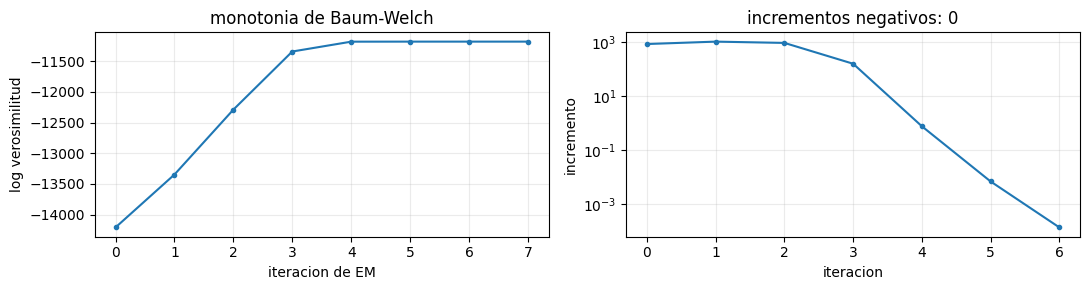

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.0))
ax[0].plot(recuperado["historia"], marker="o", ms=3)
ax[0].set_xlabel("iteracion de EM"); ax[0].set_ylabel("log verosimilitud")
ax[0].set_title("monotonia de Baum-Welch")

d_ll = np.diff(recuperado["historia"])
ax[1].semilogy(np.maximum(d_ll, 1e-12), marker="o", ms=3)
ax[1].set_xlabel("iteracion"); ax[1].set_ylabel("incremento")
ax[1].set_title(f"incrementos negativos: {int((d_ll < -1e-6).sum())}")
fig.tight_layout()

**Lo que muestran las graficas.** La log verosimilitud sube de forma monotona desde $-14\,200$ hasta $-11\,180$ y se aplana a partir de la cuarta iteracion; los incrementos caen de $10^3$ a $10^{-4}$ y ninguno es negativo. Es la propiedad que el capitulo demuestra para EM en la seccion 3.9 y que hereda Baum-Welch: cada iteracion produce parametros con verosimilitud mayor o igual que la anterior. Un incremento negativo delataria un error de implementacion.

## 1. Carga de CMAPSS

Los archivos `train_FD001.txt` y `test_FD001.txt` se descargan del portal de datos abiertos de NASA y se dejan en la carpeta `datos/`. El archivo no trae encabezado: son 26 columnas separadas por espacios, motor, ciclo, tres ajustes operacionales y veintiun sensores.

Si la carpeta no existe, la celda genera un sustituto simulado con degradacion progresiva para que el resto del cuaderno corra. En esta ejecucion la carpeta no existia, asi que todos los resultados que siguen son sobre el sustituto: sirven para validar el metodo y para leer como se comporta el HMM, no como resultado sobre motores reales.

**Que hace esta celda.** Intenta leer `datos/train_FD001.txt`; si no existe, construye el sustituto con `simular_cmapss`. Conviene entender como esta construido el sustituto porque condiciona todo lo que sigue:

- Cada motor vive entre 140 y 330 ciclos. Su "salud" es una curva que va de 0 a 1 con forma de potencia (`linspace ** uniform(1.5, 3.0)`): la degradacion empieza lenta y se acelera al final.
- Cada motor tiene una firma propia (`base`), un desplazamiento aleatorio por sensor que se mantiene constante durante toda su vida.
- La degradacion (`deriva`) empuja cada sensor en una direccion sorteada por ciclo (60 % hacia arriba, 40 % hacia abajo) con una magnitud que crece con la salud y con el indice del sensor.
- Siete sensores se fijan en 1.0 para imitar los sensores constantes del CMAPSS real.

Es decir, el sustituto tiene dos fuentes de variacion entre motores: la firma (que no dice nada de salud) y la degradacion (que si). Un buen modelo deberia separar la segunda de la primera.

In [10]:
CARPETA = Path("datos")
ARCHIVO = CARPETA / "train_FD001.txt"

COLUMNAS = (["motor", "ciclo"] + [f"op{i}" for i in range(1, 4)]
            + [f"s{i}" for i in range(1, 22)])


def simular_cmapss(n_motores=60, semilla=SEED):
    gen = np.random.default_rng(semilla)
    filas = []
    for m in range(1, n_motores + 1):
        T = int(gen.integers(140, 330))
        salud = np.clip(np.linspace(0.0, 1.0, T) ** gen.uniform(1.5, 3.0), 0, 1)
        base = gen.normal(0, 1, 21) * 0.4
        for t in range(T):
            deriva = salud[t] * np.linspace(0.2, 3.0, 21) * gen.choice([-1, 1], 21, p=[0.4, 0.6])
            s = 500 + 50 * base + 50 * deriva + gen.normal(0, 4.0, 21)
            s[[0, 4, 5, 9, 15, 17, 18]] = 1.0
            filas.append([m, t + 1] + list(gen.normal(0, 0.002, 3)) + list(s))
    return pd.DataFrame(filas, columns=COLUMNAS)


if ARCHIVO.exists():
    crudo = pd.read_csv(ARCHIVO, sep=r"\s+", header=None).iloc[:, :26]
    crudo.columns = COLUMNAS
    SIMULADO = False
else:
    crudo = simular_cmapss()
    SIMULADO = True

pd.Series({"origen": "archivo NASA" if not SIMULADO else "sustituto simulado",
           "filas": len(crudo), "motores": crudo["motor"].nunique(),
           "ciclos por motor (mediana)": float(crudo.groupby("motor").size().median())})

origen                        sustituto simulado
filas                                      13739
motores                                       60
ciclos por motor (mediana)                 217.5
dtype: object

**Como leer la salida.** Se usa el sustituto: 60 motores, 13.739 ciclos en total, mediana de 217 ciclos por motor.

**Que hace esta celda.** A la izquierda, el histograma de la vida de cada motor (ciclos hasta el fallo). A la derecha, la trayectoria del sensor 11 en seis motores, para ver a simple vista si hay una tendencia hacia el final de la vida y cuanto ruido la acompana.

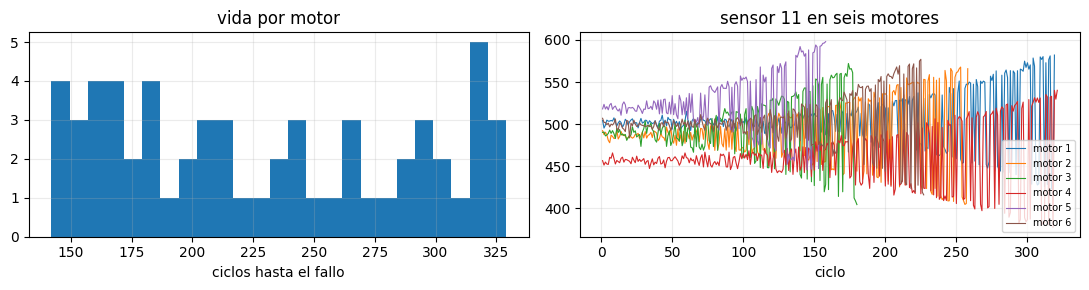

In [11]:
vida = crudo.groupby("motor").size()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.0))
ax[0].hist(vida, bins=25)
ax[0].set_xlabel("ciclos hasta el fallo"); ax[0].set_title("vida por motor")
for m in crudo["motor"].unique()[:6]:
    sub = crudo[crudo["motor"] == m]
    ax[1].plot(sub["ciclo"], sub["s11"], lw=0.8, label=f"motor {m}")
ax[1].set_xlabel("ciclo"); ax[1].set_title("sensor 11 en seis motores"); ax[1].legend(fontsize=7)
fig.tight_layout()

**Lo que muestran las graficas.** Las vidas se reparten de manera aproximadamente uniforme entre 140 y 330 ciclos, como las genera el simulador. En el sensor 11 cada motor arranca en un nivel distinto (la firma) y el ruido ciclo a ciclo es grande frente a la deriva, que solo se insinua en los ultimos ciclos. Esa relacion senal a ruido es la que hace util un modelo secuencial: un ciclo aislado no dice casi nada sobre la salud, pero la acumulacion de evidencia a lo largo de la secuencia, que es lo que hace la recursion hacia adelante, si.

## 2. Seleccion de sensores

Se retiran los sensores constantes o casi constantes. El criterio se calcula solo sobre los motores de entrenamiento.

**Que hace esta celda.** Parte los motores en 70 % para entrenamiento y 30 % para prueba (por motor, no por ciclo: un motor completo va a un solo bloque) y, solo con los motores de entrenamiento, calcula la desviacion y el numero de valores distintos de cada sensor. Se conservan los sensores con desviacion positiva y mas de cinco valores distintos.

**Por que por motor.** Las observaciones de un mismo motor no son independientes; si los ciclos de un motor se repartieran entre entrenamiento y prueba, el modelo evaluaria en ciclos vecinos de los que ya vio. Partir por unidad es la unica forma de medir generalizacion a motores nuevos.

In [12]:
motores = np.sort(crudo["motor"].unique())
rng_part = np.random.default_rng(SEED)
mezcla = rng_part.permutation(motores)
corte = int(0.70 * len(mezcla))
MOT_TR, MOT_TE = np.sort(mezcla[:corte]), np.sort(mezcla[corte:])

sensores = [f"s{i}" for i in range(1, 22)]
tr = crudo[crudo["motor"].isin(MOT_TR)]

desc = pd.DataFrame({"sd": tr[sensores].std(ddof=1),
                     "valores distintos": tr[sensores].nunique()})
desc["conservar"] = (desc["sd"] > 1e-6) & (desc["valores distintos"] > 5)

SENSORES = desc.index[desc["conservar"]].tolist()
desc

,sd,valores distintos,conservar
s1,0.000000,1,False
s2,23.637489,9819,True
s3,19.785771,9819,True
s4,26.029983,9819,True
s5,0.000000,1,False
s6,0.000000,1,False
s7,28.245131,9819,True
s8,32.270746,9819,True
s9,35.138514,9819,True
s10,0.000000,1,False


**Como leer la salida.** Siete sensores (s1, s5, s6, s10, s16, s18, s19) tienen desviacion cero y un solo valor: son los constantes del simulador y no aportan informacion; ademas, una variable constante tiene varianza cero y haria singular cualquier covarianza. Quedan 14 sensores.

**Que hace esta celda.** Estandariza los 14 sensores con la media y la desviacion de los motores de entrenamiento y construye una matriz por motor, ordenada por ciclo. `SEC_TR` y `SEC_TE` son listas de secuencias, que es el formato que reciben las funciones del HMM: cada motor es una secuencia independiente con su propia longitud.

In [13]:
media_tr = tr[SENSORES].mean()
sd_tr = tr[SENSORES].std(ddof=0).replace(0.0, 1.0)


def secuencias_de(motores_sel):
    salida, ids = [], []
    for m in motores_sel:
        sub = crudo[crudo["motor"] == m].sort_values("ciclo")
        Z = ((sub[SENSORES] - media_tr) / sd_tr).to_numpy(dtype=float)
        salida.append(Z)
        ids.append(m)
    return salida, ids


SEC_TR, ID_TR = secuencias_de(MOT_TR)
SEC_TE, ID_TE = secuencias_de(MOT_TE)

pd.Series({"sensores conservados": len(SENSORES),
           "motores entrenamiento": len(SEC_TR), "motores prueba": len(SEC_TE),
           "ciclos entrenamiento": int(sum(len(s) for s in SEC_TR)),
           "ciclos prueba": int(sum(len(s) for s in SEC_TE))})

sensores conservados       14
motores entrenamiento      42
motores prueba             18
ciclos entrenamiento     9819
ciclos prueba            3920
dtype: int64

**Como leer la salida.** 42 motores de entrenamiento con 9.819 ciclos y 18 de prueba con 3.920, en 14 dimensiones.

## 3. Seleccion del numero de estados

Se comparan modelos con 2, 3, 4 y 5 estados por log verosimilitud sobre los motores no vistos, no sobre los de ajuste. Se reporta ademas BIC sobre entrenamiento para contrastar los dos criterios.

El barrido corre con un presupuesto corto de iteraciones para que sea manejable. El modelo elegido se reajusta despues con el presupuesto completo.

**Que hace esta celda.** Para $K = 2, 3, 4, 5$ ajusta un HMM progresivo con covarianza diagonal (5 reinicios, 60 iteraciones) sobre los motores de entrenamiento y registra la log verosimilitud en entrenamiento, la log verosimilitud sobre los motores de prueba (total y por ciclo), el numero de parametros, el BIC de entrenamiento y la dispersion de la log verosimilitud entre reinicios.

**Conexion con el libro.** Elegir $K$ es elegir la complejidad del modelo, y el capitulo advierte en la seccion 3.7.3 que mas parametros siempre mejoran el ajuste en entrenamiento y no necesariamente en datos nuevos. Por eso el criterio principal es la log verosimilitud en motores no vistos. El BIC es la alternativa que no necesita datos de prueba: penaliza cada parametro con $\log n$. La dispersion entre reinicios mide cuanto dependen los resultados del punto de partida de EM, que es el problema de optimos locales de la seccion 3.9.

In [14]:
REINICIOS = 5
n_obs_tr = sum(len(s) for s in SEC_TR)

comparacion = []
modelos_K = {}
for K in [2, 3, 4, 5]:
    m = ajustar_hmm(SEC_TR, K, reinicios=REINICIOS, semilla=SEED,
                    tipo="diagonal", progresiva=True, iteraciones=60)
    modelos_K[K] = m
    ll_te = log_verosimilitud(m, SEC_TE)
    ic = aic_bic(m["loglik"], K, m["d"], n_obs_tr, tipo="diagonal", progresiva=True)
    comparacion.append({"K": K, "loglik entrenamiento": m["loglik"],
                        "loglik prueba": ll_te,
                        "loglik prueba por ciclo": ll_te / sum(len(s) for s in SEC_TE),
                        "parametros": ic["parametros"], "bic entrenamiento": ic["bic"],
                        "dispersion entre reinicios": float(m["reinicios"]["loglik"].std())})

comparacion = pd.DataFrame(comparacion).set_index("K")
comparacion.round(2)

,loglik entrenamiento,loglik prueba,loglik prueba por ciclo,parametros,bic entrenamiento,dispersion entre reinicios
K,,,,,,
2,-170003.83,-64233.09,-16.39,58,340540.80,11836.83
3,-164936.03,-63700.56,-16.25,89,330690.15,1666.45
4,-161862.26,-62932.30,-16.05,121,324836.76,897.68
5,-157878.48,-62415.80,-15.92,154,317172.54,2568.58


**Como leer la salida.** La log verosimilitud de prueba por ciclo mejora de forma monotona con $K$: $-16{,}39$, $-16{,}25$, $-16{,}05$, $-15{,}92$. El BIC de entrenamiento tambien baja con $K$. Ninguno de los dos criterios se detiene en 2, 3, 4 o 5: cada estado adicional sigue comprando ajuste. Eso no significa que haya cinco etapas de degradacion; significa que las emisiones gaussianas diagonales son una descripcion pobre de la nube de sensores (los sensores estan correlacionados y cada motor tiene su firma), y el modelo usa estados adicionales para aproximar esa estructura. Es la advertencia de la seccion 3.7.3 leida al reves: cuando el modelo de emision es demasiado simple, agregar estados es la unica forma que tiene EM de mejorar la verosimilitud, y el criterio de complejidad deja de discriminar. La dispersion entre reinicios (11.837 con $K = 2$, 898 con $K = 4$) muestra ademas que la superficie de verosimilitud tiene varios optimos locales. Se sigue con $K = 3$ por interpretabilidad, como propone el enunciado, sabiendo que no es el $K$ que maximiza el ajuste.

**Que hace esta celda.** Dibuja la log verosimilitud de prueba por ciclo y el BIC de entrenamiento frente a $K$.

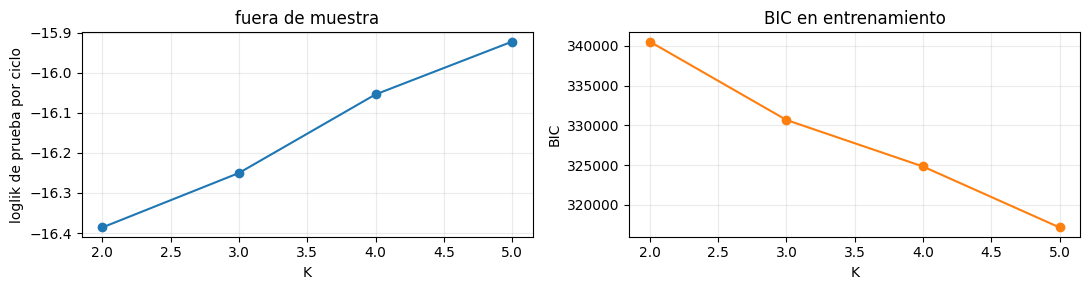

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.0))
ax[0].plot(comparacion.index, comparacion["loglik prueba por ciclo"], marker="o")
ax[0].set_xlabel("K"); ax[0].set_ylabel("loglik de prueba por ciclo"); ax[0].set_title("fuera de muestra")
ax[1].plot(comparacion.index, comparacion["bic entrenamiento"], marker="o", color="tab:orange")
ax[1].set_xlabel("K"); ax[1].set_ylabel("BIC"); ax[1].set_title("BIC en entrenamiento")
fig.tight_layout()

**Lo que muestran las graficas.** Ambas curvas son monotonas: la log verosimilitud de prueba sube y el BIC baja al aumentar $K$, sin un codo claro. Cuando los dos criterios coinciden en no penalizar la complejidad, la eleccion de $K$ tiene que venir de fuera del ajuste, aqui de la interpretabilidad que pide el enunciado.

## 4. Modelo de tres estados

Tres estados corresponden a la lectura interpretable que propone el enunciado: saludable, degradacion inicial y degradacion severa. Los estados se reetiquetan por la media del primer sensor conservado para que el orden sea estable entre corridas.

**Que hace esta celda.** Ajusta el modelo final con $K = 3$ y el presupuesto completo de iteraciones, y reetiqueta los estados por la media del primer sensor conservado (s2) de menor a mayor. Muestra la matriz de transicion $A$ aprendida.

**Sobre el reetiquetado.** Las etiquetas de un HMM son arbitrarias, y ordenar por la media de un sensor solo garantiza que el orden sea reproducible entre corridas; no garantiza que el estado de mayor indice sea el mas degradado. Eso hay que comprobarlo mirando $A$ y los perfiles, y es lo que se hace en las celdas siguientes.

In [16]:
K = 3
ajuste = ajustar_hmm(SEC_TR, K, reinicios=REINICIOS, semilla=SEED,
                     tipo="diagonal", progresiva=True, iteraciones=400)
modelo = ordenar_por_media(ajuste, columna=0)

pd.DataFrame(modelo["A"], index=[f"desde {j}" for j in range(K)],
             columns=[f"hacia {j}" for j in range(K)]).round(4)

,hacia 0,hacia 1,hacia 2
desde 0,0.993,0.0070,0.0000
desde 1,0.000,1.0000,0.0000
desde 2,0.000,0.0072,0.9928


**Como leer la matriz.** La fila del estado 1 es $(0, 1, 0)$: una vez que la cadena entra al estado 1, no sale. Es un estado absorbente, y con la mascara progresiva la cadena solo puede moverse hacia el, desde el estado 0 con probabilidad 0,007 por ciclo y desde el estado 2 con 0,0072. Notese que el estado absorbente es el 1 y no el 2: el reetiquetado por la media de s2 no coloco al estado final en la ultima posicion. Esta observacion es la que obliga, en la seccion 6, a identificar el estado severo por su comportamiento en $A$ y no por su indice.

**Que hace esta celda.** Para cada estado muestra la probabilidad inicial $\pi_j$, la duracion media $1/(1 - a_{jj})$ y la ocupacion estacionaria. Con una transicion progresiva y un estado del que no se sale, la ocupacion estacionaria se concentra por completo en ese estado absorbente.

In [17]:
pd.DataFrame({"probabilidad inicial": modelo["pi"],
              "duracion media en ciclos": duracion_media(modelo["A"]),
              "ocupacion estacionaria": estacionaria(modelo["A"])},
             index=[f"estado {j}" for j in range(K)]).round(4)

,probabilidad inicial,duracion media en ciclos,ocupacion estacionaria
estado 0,0.5952,1.424632e+02,0.0
estado 1,0.0000,1.000022e+12,1.0
estado 2,0.4048,1.394788e+02,0.0


**Como leer la salida.** Los motores empiezan en el estado 0 (60 %) o en el 2 (40 %), nunca en el 1. La duracion media del 0 es 142 ciclos y la del 2 es 139; la del 1 es $10^{12}$, que es la manera numerica de decir "infinita": $1/(1 - a_{jj})$ con $a_{jj} = 1$. La ocupacion estacionaria es 1 en el estado 1 y 0 en los otros dos, como corresponde a una cadena con un unico estado absorbente. Todo apunta a que el estado 1 es la fase final de degradacion y que 0 y 2 son dos versiones del estado sano.

**Que hace esta celda.** Dibuja los perfiles de emision $\mu_j$: la media estandarizada de cada sensor en cada estado. Es la forma de "leer" que significa cada estado, tal como recomienda el enunciado: sin imponer etiquetas de antemano, sino mirando que valores de sensores caracterizan a cada uno.

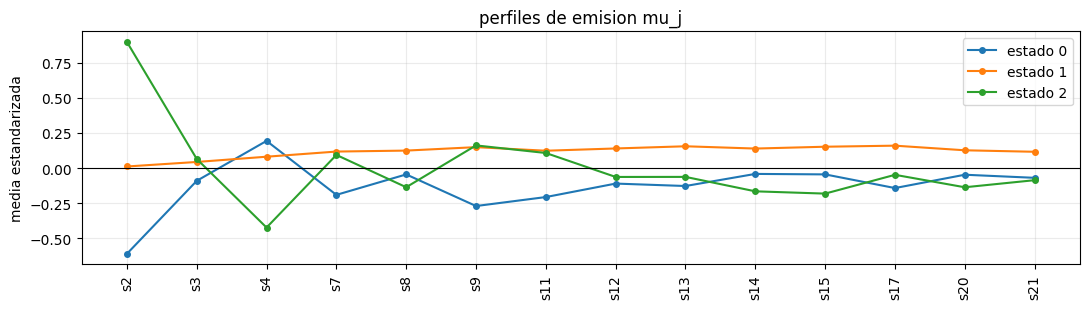

In [18]:
perfiles = pd.DataFrame(modelo["mus"], columns=SENSORES,
                        index=[f"estado {j}" for j in range(K)])

fig, ax = plt.subplots(figsize=(11, 3.2))
for j in range(K):
    ax.plot(SENSORES, perfiles.iloc[j], marker="o", ms=4, label=f"estado {j}")
ax.axhline(0.0, color="black", lw=0.8)
ax.set_ylabel("media estandarizada"); ax.set_title("perfiles de emision mu_j")
ax.tick_params(axis="x", rotation=90); ax.legend()
fig.tight_layout()

**Lo que muestra la grafica.** El estado 1 (naranja) tiene todos los sensores ligeramente por encima de la media, entre 0,1 y 0,15 desviaciones, de forma uniforme: es el perfil de un motor degradado, en el que la deriva del simulador empuja la mayoria de los sensores hacia arriba. Los estados 0 (azul) y 2 (rojo) son imagenes casi especulares en s2 y s4: uno tiene s2 muy bajo y s4 alto, el otro s2 muy alto y s4 bajo, y en el resto de sensores ambos estan un poco por debajo de la media. Eso no es degradacion: es la firma propia de cada motor, el desplazamiento `base` del simulador, que en s2 y s4 resulta especialmente grande. El HMM dedico dos de sus tres estados a distinguir familias de motores y uno a la degradacion. Es un resultado coherente con como se construyo el sustituto (la firma es una fuente de variacion tan grande como la deriva) y una leccion sobre la hipotesis de homogeneidad entre motores que se discute en la seccion 9.

**Que hace esta celda.** Tabla de los cinco reinicios del ajuste final: semilla, log verosimilitud alcanzada e iteraciones. Es la evidencia directa de los optimos locales de EM.

In [19]:
ajuste["reinicios"].round(2)

,semilla,loglik,iteraciones
0,7,-167922.54,13
1,1007,-167717.59,13
2,2007,-164979.77,23
3,3007,-164936.03,16
4,4007,-168291.04,11


**Como leer la salida.** Dos reinicios (semillas 2007 y 3007) llegan a log verosimilitudes casi iguales ($-164\,980$ y $-164\,936$) y los otros tres se quedan unos 3.000 puntos por debajo. EM no encuentra el mismo optimo desde cualquier punto de partida, como advierte la seccion 3.9, y con un solo reinicio habria un 60 % de probabilidad de quedarse con una solucion claramente peor. La corrida elegida es la de la semilla 3007.

## 5. Decodificacion por motor

Viterbi sobre motores no usados en el ajuste. Se contrasta la trayectoria global de Viterbi contra el filtrado en linea, que solo usa el pasado.

**Que hace esta celda.** Para seis motores de prueba dibuja la ruta de Viterbi (linea negra escalonada, con el indice del estado en el eje vertical) y, superpuestas, las probabilidades filtradas de cada estado reescaladas al mismo eje. La comparacion entre ambas muestra cuanto se adelanta o se retrasa la version en linea respecto de la decodificacion con toda la secuencia.

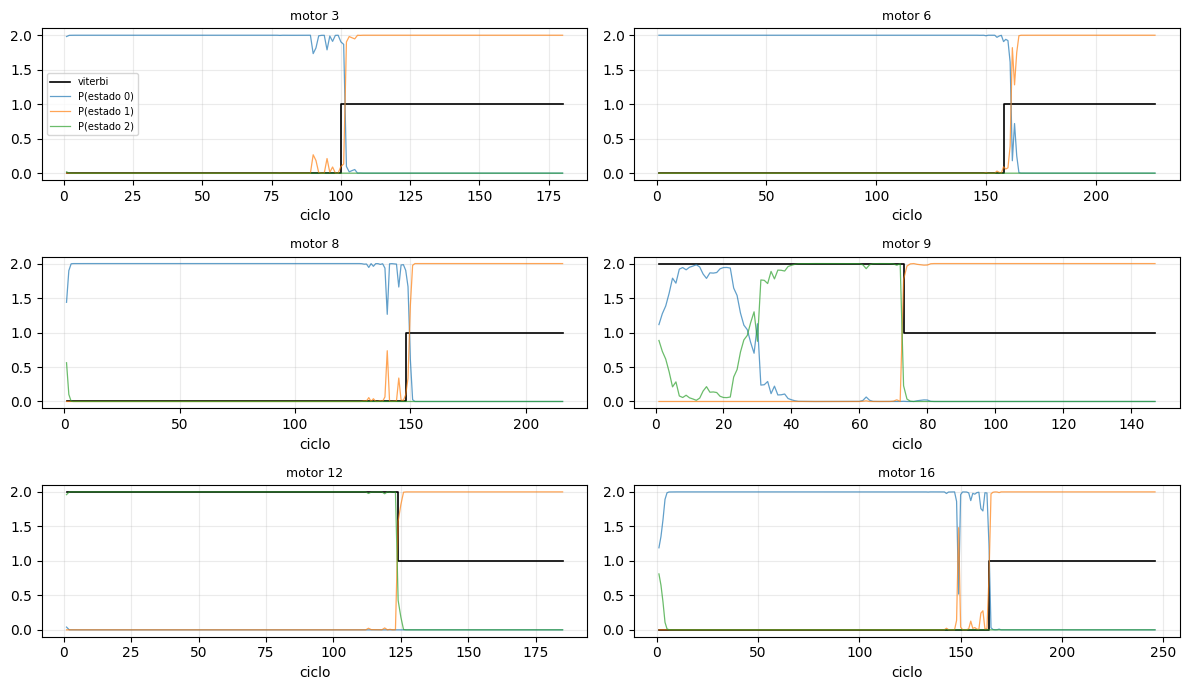

In [20]:
fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=False)
for a, m in zip(ax.ravel(), ID_TE[:6]):
    i = ID_TE.index(m)
    X = SEC_TE[i]
    ruta = estados(modelo, X, modo="viterbi")
    prob = estados(modelo, X, modo="filtrado")
    ciclos = np.arange(1, len(X) + 1)
    a.plot(ciclos, ruta, drawstyle="steps-post", lw=1.2, color="black", label="viterbi")
    for j in range(K):
        a.plot(ciclos, prob[:, j] * (K - 1), lw=0.9, alpha=0.7, label=f"P(estado {j})")
    a.set_title(f"motor {m}", fontsize=9); a.set_xlabel("ciclo")
ax[0, 0].legend(fontsize=7)
fig.tight_layout()

**Lo que muestra la grafica.** En los seis motores la ruta de Viterbi (negra) tiene un unico salto: el motor arranca en el estado 0 o en el 2 y en algun ciclo cambia al estado 1, donde permanece hasta el fallo. Las probabilidades filtradas cuentan la version en tiempo real: la curva del estado inicial se mantiene en 1 y la del estado 1 sube de golpe al llegar al cambio, con algun titubeo de pocos ciclos justo antes (motores 3, 6 y 16), que es el intervalo en que la evidencia acumulada todavia no alcanza para decidir. El motor 9 es el caso interesante: en sus primeros cuarenta ciclos el filtrado duda entre los estados 0 y 2, porque su firma esta a medio camino entre las dos familias, mientras Viterbi, que ve toda la secuencia, lo asigna al 2 sin dudar. Es la diferencia entre decidir con el pasado y decidir con todo.

**Que hace esta celda.** Para cada motor de prueba y cada estado cuenta cuantos ciclos pasa en el, que fraccion de la vida representan y en que ciclo aparece por primera vez, y resume media y desviacion por estado.

In [21]:
filas = []
for i, m in enumerate(ID_TE):
    X = SEC_TE[i]
    ruta = estados(modelo, X, modo="viterbi")
    T = len(X)
    for j in range(K):
        presente = np.flatnonzero(ruta == j)
        filas.append({"motor": m, "estado": j, "ciclos": len(presente),
                      "fraccion de vida": len(presente) / T,
                      "primer ciclo": int(presente[0]) + 1 if len(presente) else None})

ocupacion = pd.DataFrame(filas)
ocupacion.groupby("estado")[["ciclos", "fraccion de vida"]].agg(["mean", "std"]).round(3)

ciclos         fraccion de vida       
          mean     std             mean    std
estado                                        
0       82.222  73.160            0.384  0.321
1       85.278  31.368            0.391  0.084
2       50.278  71.593            0.226  0.296

**Como leer la salida.** El estado 1 ocupa en promedio 85 ciclos por motor, el 39 % de la vida, con una desviacion pequena (8 puntos porcentuales): la fase final tiene una duracion relativamente estable en fraccion de vida. Los estados 0 y 2 tienen desviaciones enormes (0,32 y 0,30 en fraccion de vida) porque cada motor esta en uno u otro, no en los dos: un motor pasa el 60 % de su vida en el 0 o el 60 % en el 2.

## 6. Alerta temprana

Se declara alerta cuando la probabilidad filtrada del estado mas degradado supera un umbral durante varios ciclos seguidos. La anticipacion es el numero de ciclos entre la alerta y el ultimo ciclo registrado del motor.

**Que hace esta celda.** Define la alerta temprana y mide su anticipacion. `anticipacion` recorre la probabilidad filtrada del estado severo y devuelve cuantos ciclos faltaban para el fallo cuando esa probabilidad supero el umbral durante `persistencia` ciclos seguidos. La tabla recorre tres umbrales y tres persistencias.

**Que estado es el severo.** No es automaticamente el de indice $K - 1$: el reetiquetado de la seccion 4 ordena por la media de un sensor, y en este ajuste el estado absorbente (el que tiene $a_{jj} = 1$, en el que terminan todas las trayectorias y que concentra toda la ocupacion estacionaria) es el estado 1. Por eso el estado severo se identifica como el de mayor ocupacion estacionaria, que es la definicion coherente con una cadena progresiva: el estado del que ya no se sale es el final de la degradacion.

**Conexion con el libro.** La alerta usa $P(Z_t = \text{severo} \mid X_{1:t})$, la probabilidad filtrada que da la recursion hacia adelante de la seccion 3.10.3 normalizada en cada paso. Es una decision bayesiana secuencial: en cada ciclo se compara la posterior del estado con un umbral, exactamente como la regla de Bayes del capitulo 2 compara posteriores, pero con la posterior actualizada dato a dato.

In [22]:
# El estado severo es el absorbente: aquel en el que terminan las trayectorias y que concentra
# toda la ocupacion estacionaria. No tiene por que ser el de indice K - 1, porque el reetiquetado
# de la seccion 4 ordena por la media de un sensor, no por la salud del motor.
SEVERO = int(np.argmax(estacionaria(modelo["A"])))
print(f"estado severo (absorbente): {SEVERO}, con a_jj = {modelo['A'][SEVERO, SEVERO]:.4f}")


def anticipacion(X, umbral, persistencia):
    prob = estados(modelo, X, modo="filtrado")[:, SEVERO]
    corrida = 0
    for t, p in enumerate(prob):
        corrida = corrida + 1 if p > umbral else 0
        if corrida >= persistencia:
            return len(X) - t
    return None


filas = []
for umbral in [0.5, 0.7, 0.9]:
    for persistencia in [1, 5, 10]:
        antic = [anticipacion(X, umbral, persistencia) for X in SEC_TE]
        detectados = [a for a in antic if a is not None]
        filas.append({"umbral": umbral, "persistencia": persistencia,
                      "motores con alerta": len(detectados),
                      "de": len(SEC_TE),
                      "anticipacion mediana": float(np.median(detectados)) if detectados else None,
                      "anticipacion minima": float(np.min(detectados)) if detectados else None})

pd.DataFrame(filas)

estado severo (absorbente): 1, con a_jj = 1.0000


,umbral,persistencia,motores con alerta,de,anticipacion mediana,anticipacion minima
0,0.5,1,18,18,75.5,45.0
1,0.5,5,18,18,71.5,41.0
2,0.5,10,18,18,66.5,36.0
3,0.7,1,18,18,75.5,45.0
4,0.7,5,18,18,71.5,41.0
5,0.7,10,18,18,66.5,36.0
6,0.9,1,18,18,74.5,44.0
7,0.9,5,18,18,70.5,40.0
8,0.9,10,18,18,65.5,35.0


**Como leer la salida.** El estado severo identificado es el 1, con $a_{11} = 1$. Con cualquiera de las nueve combinaciones de umbral y persistencia, los 18 motores de prueba reciben alerta. Con umbral 0,7 y persistencia 5 ciclos la anticipacion mediana es de 71,5 ciclos y la minima de 41: el motor peor anticipado recibe la alerta 41 ciclos antes de fallar. Subir el umbral de 0,5 a 0,9 apenas cambia la anticipacion (de 75,5 a 74,5 en la mediana con persistencia 1), porque la probabilidad filtrada del estado 1 salta de casi 0 a casi 1 en pocos ciclos; lo que si la reduce es la persistencia, que por construccion resta ciclos (de 75,5 a 66,5 al pasar de 1 a 10). La eleccion de la persistencia es entonces un compromiso entre falsas alarmas por titubeos como los del motor 16 y ciclos de anticipacion perdidos.

**Que hace esta celda.** Con umbral 0,7 y persistencia 5, el histograma de la anticipacion en ciclos y su relacion con la vida total de cada motor.

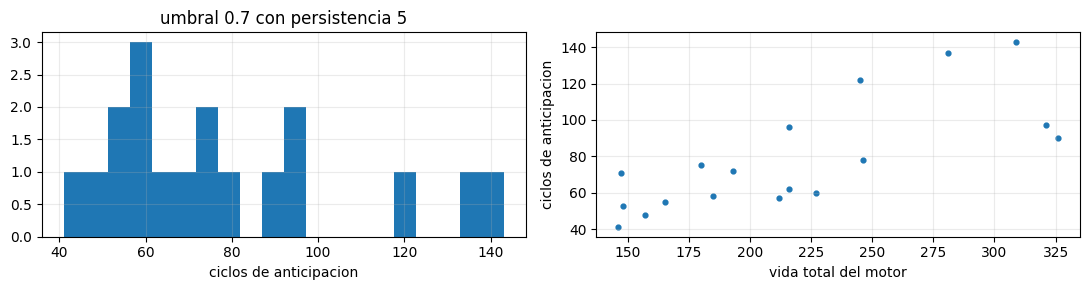

In [23]:
antic = [anticipacion(X, 0.7, 5) for X in SEC_TE]
validos = [a for a in antic if a is not None]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.0))
ax[0].hist(validos, bins=20)
ax[0].set_xlabel("ciclos de anticipacion"); ax[0].set_title("umbral 0.7 con persistencia 5")
ax[1].scatter([len(X) for X, a in zip(SEC_TE, antic) if a is not None], validos, s=12)
ax[1].set_xlabel("vida total del motor"); ax[1].set_ylabel("ciclos de anticipacion")
fig.tight_layout()

**Lo que muestran las graficas.** La anticipacion va de 41 a 143 ciclos y crece con la vida total del motor: los motores que viven 300 ciclos reciben la alerta con mas de 100 ciclos de margen, los que viven 150 con unos 50. Es consistente con el simulador, en el que la degradacion ocupa una fraccion de la vida y no un numero fijo de ciclos, y con la tabla de ocupacion (el estado 1 dura el 39 % de la vida en promedio). Para un sistema de mantenimiento esto significa que la alerta se puede leer en fraccion de vida remanente y no solo en ciclos.

## 7. Filtrado frente a Viterbi

El filtrado solo usa el pasado, asi que es la version disponible en operacion. Viterbi usa la secuencia completa, asi que es una referencia optimista. La diferencia entre los dos mide cuanto se pierde por no poder mirar el futuro.

**Que hace esta celda.** Para cada motor de prueba compara tres decodificaciones: Viterbi (usa toda la secuencia), filtrado (solo el pasado, tomando en cada ciclo el estado de mayor probabilidad) y suavizado (el estado de mayor $\gamma_t$, que tambien usa toda la secuencia). Reporta la coincidencia con Viterbi y el numero de cambios de estado de cada una.

**Conexion con el libro.** Son las tres lecturas posibles de la seccion 3.10.3: $\alpha_t$ normalizada (filtrado), $\gamma_t = \alpha_t\beta_t / P(X)$ (suavizado) y el camino de Viterbi. El suavizado y Viterbi usan el futuro y por eso no estan disponibles en operacion; el filtrado si. La diferencia entre ellos es el precio de decidir sin ver el futuro.

In [24]:
filas = []
for i, m in enumerate(ID_TE):
    X = SEC_TE[i]
    ruta = estados(modelo, X, modo="viterbi")
    en_linea = np.argmax(estados(modelo, X, modo="filtrado"), axis=1)
    suave = np.argmax(estados(modelo, X, modo="suavizado"), axis=1)
    filas.append({"motor": m,
                  "coincidencia filtrado y viterbi": float(np.mean(en_linea == ruta)),
                  "coincidencia suavizado y viterbi": float(np.mean(suave == ruta)),
                  "cambios de estado en viterbi": int((np.diff(ruta) != 0).sum()),
                  "cambios de estado en filtrado": int((np.diff(en_linea) != 0).sum())})

comp = pd.DataFrame(filas)
comp.describe().loc[["mean", "std", "min", "max"]].round(4)

,motor,coincidencia filtrado y viterbi,coincidencia suavizado y viterbi,cambios de estado en viterbi,cambios de estado en filtrado
mean,25.6667,0.9786,0.9990,1.0,2.7778
std,14.0503,0.0429,0.0023,0.0,1.9571
min,3.0000,0.8095,0.9932,1.0,1.0000
max,49.0000,1.0000,1.0000,1.0,6.0000


**Como leer la salida.** El filtrado coincide con Viterbi en el 97,9 % de los ciclos en promedio (minimo 81 % en un motor) y el suavizado en el 99,9 %. Viterbi produce exactamente un cambio de estado por motor, mientras el filtrado produce 2,8 en promedio y hasta 6: son los titubeos previos al cambio, en los que la probabilidad cruza y vuelve a cruzar el 50 % antes de asentarse. La persistencia de la seccion 6 existe para no disparar en esos titubeos. El precio de no ver el futuro es pequeno aqui porque el cambio de estado es abrupto; seria mayor si la transicion fuera gradual.

## 8. Estabilidad ante inicializaciones

Se contrasta el mejor ajuste contra los demas reinicios para ver si convergen al mismo optimo o si la superficie de verosimilitud tiene varios maximos locales.

**Que hace esta celda.** Reetiqueta cada reinicio con el mismo criterio y lo compara con el mejor: brecha de log verosimilitud, distancia maxima entre medias y distancia maxima entre matrices de transicion. Si todos los reinicios llegaran al mismo optimo, las tres columnas serian cero.

In [25]:
corridas = ajuste["corridas"]

filas = []
ref = ordenar_por_media(max(corridas, key=lambda m: m["loglik"]), columna=0)
for r, c in enumerate(corridas):
    o = ordenar_por_media(c, columna=0)
    filas.append({"reinicio": r, "loglik": c["loglik"], "iteraciones": c["iteraciones"],
                  "brecha con el mejor": c["loglik"] - ref["loglik"],
                  "distancia maxima en mu": float(np.max(np.abs(o["mus"] - ref["mus"]))),
                  "distancia maxima en A": float(np.max(np.abs(o["A"] - ref["A"])))})

pd.DataFrame(filas).round(4)

,reinicio,loglik,iteraciones,brecha con el mejor,distancia maxima en mu,distancia maxima en A
0,0,-167922.5445,13,-2986.5176,0.3345,0.0075
1,1,-167717.5914,13,-2781.5645,1.0189,0.0079
2,2,-164979.7723,23,-43.7454,0.7409,0.0093
3,3,-164936.0270,16,0.0000,0.0000,0.0000
4,4,-168291.0442,11,-3355.0172,1.0017,0.0074


**Como leer la salida.** Los reinicios 2 y 3 comparten practicamente la misma solucion (brecha de 44 en log verosimilitud, distancia 0,009 en $A$), pero sus medias difieren hasta 0,74 desviaciones: el mismo optimo con los estados 0 y 2 intercambiados en algun sensor, que el reetiquetado por s2 no alcanza a alinear del todo. Los reinicios 0, 1 y 4 estan a 2.800 o mas de log verosimilitud y con medias que difieren hasta 1,0: son optimos locales distintos. En $A$ todos coinciden en la centesima, porque la estructura progresiva con un absorbente es lo primero que EM encuentra desde cualquier inicio; lo que cambia entre optimos es como reparte los motores sanos entre los estados 0 y 2.

## 9. Diagnostico de supuestos

El HMM del capitulo descansa en hipotesis que aqui se pueden contrastar una por una con lo ya calculado.

**Markov de primer orden.** La probabilidad de transicion depende solo del estado anterior, no del tiempo que la cadena lleva en el. Eso impone una duracion geometrica en cada estado (seccion 3.10.1), con media $1/(1 - a_{jj})$. La celda siguiente compara esa duracion implicada con la distribucion de duraciones observada en las rutas de Viterbi; una discrepancia grande indica que el proceso real tiene memoria de cuanto lleva en cada etapa, como es de esperar en una degradacion que avanza con el uso.

**Emisiones gaussianas con covarianza diagonal.** Los sensores de un motor estan correlacionados entre si, asi que la diagonal es un supuesto de conveniencia numerica (seccion 3.7.3: menos parametros por estado) y no una descripcion fisica. Las medias por estado siguen siendo interpretables, pero la forma de la nube de cada estado no.

**Homogeneidad entre motores.** Una sola matriz $A$ y un solo juego de emisiones para todos los motores supone que todos degradan con la misma dinamica y tienen la misma firma de sensores. Los perfiles de emision de la seccion 4 muestran que esta hipotesis falla en el sustituto simulado: dos de los tres estados capturan diferencias de firma entre motores y no etapas de degradacion.

**Transicion progresiva.** Impedir el retorno es una decision de modelado, no un hallazgo. La ultima celda compara contra el modelo sin la mascara para medir cuanto cuesta la restriccion en verosimilitud.

**Que hace esta celda.** Recorre las rutas de Viterbi de los motores de prueba, mide cuantos ciclos seguidos dura cada visita a cada estado y compara la media observada con la duracion geometrica que implica $a_{jj}$.

In [26]:
duraciones = []
for X in SEC_TE:
    ruta = estados(modelo, X, modo="viterbi")
    inicio = 0
    for t in range(1, len(ruta) + 1):
        if t == len(ruta) or ruta[t] != ruta[inicio]:
            duraciones.append({"estado": int(ruta[inicio]), "duracion": t - inicio})
            inicio = t

duraciones = pd.DataFrame(duraciones)
teorica = duracion_media(modelo["A"])

resumen = duraciones.groupby("estado")["duracion"].agg(["count", "mean", "std", "max"])
resumen["duracion geometrica implicada"] = teorica[resumen.index]
resumen.round(2)

,count,mean,std,max,duracion geometrica implicada
estado,,,,,
0,11,134.55,36.81,220,1.424600e+02
1,18,85.28,31.37,152,1.000022e+12
2,7,129.29,51.04,227,1.394800e+02


**Como leer la salida.** Para los estados 0 y 2 la duracion observada (135 y 129 ciclos) es cercana a la geometrica implicada (142 y 139), asi que en esos estados el supuesto de Markov de primer orden es aceptable. Para el estado 1 la comparacion no tiene sentido: la geometrica implicada es infinita porque es absorbente, y la duracion observada (85 ciclos) esta truncada por el fallo del motor, que el modelo no representa. Un modelo que quisiera describir tambien el fallo necesitaria un cuarto estado terminal o un modelo de supervivencia, ambos fuera del alcance del capitulo.

**Que hace esta celda.** Ajusta el mismo modelo sin la mascara progresiva y compara log verosimilitud en entrenamiento y prueba y numero de parametros. Mide cuanto "cuesta" la restriccion de no poder volver atras.

In [27]:
libre = ajustar_hmm(SEC_TR, K, reinicios=REINICIOS, semilla=SEED,
                    tipo="diagonal", progresiva=False, iteraciones=400)

pd.DataFrame({
    "progresiva": {"loglik entrenamiento": ajuste["loglik"],
                   "loglik prueba": log_verosimilitud(ajuste, SEC_TE),
                   "parametros": parametros_libres(K, modelo["d"], "diagonal", True)},
    "sin restriccion": {"loglik entrenamiento": libre["loglik"],
                        "loglik prueba": log_verosimilitud(libre, SEC_TE),
                        "parametros": parametros_libres(K, modelo["d"], "diagonal", False)},
}).round(2)

,progresiva,sin restriccion
loglik entrenamiento,-164936.03,-164701.74
loglik prueba,-63700.56,-63599.80
parametros,89.00,92.00


**Como leer la salida.** Quitar la mascara progresiva mejora la log verosimilitud en 234 puntos en entrenamiento y 101 en prueba, a cambio de 3 parametros mas. Es una mejora real pero pequena: la estructura progresiva es casi lo que EM habria encontrado solo. La restriccion cuesta poco en ajuste y compra interpretabilidad (no hay "curaciones" espontaneas en las rutas), asi que se mantiene.

## 10. Limitaciones y pregunta de investigacion

**Los estados son categorias estadisticas.** Que un estado aparezca cerca del fallo no lo convierte en una etapa fisica de degradacion identificada. La atribucion requiere contrastar los perfiles de emision contra el conocimiento de ingenieria de cada sensor y contra la tendencia monotona de los que si son indicadores de salud conocidos. En este cuaderno, con datos simulados, el contraste se hizo contra la construccion del simulador y mostro que el HMM dedico dos estados a separar firmas de motor y uno a la degradacion.

**La anticipacion medida es optimista.** Esta calculada sobre motores que corren hasta el fallo. En operacion real el motor se retira antes, asi que la distribucion de anticipacion observada no es la misma.

**Lo que el cuaderno establece.** Las tres tareas del capitulo (evaluacion, decodificacion y aprendizaje) estan implementadas y verificadas contra parametros conocidos. El modelo aprende una transicion progresiva con un estado absorbente, el filtrado en linea reproduce la ruta de Viterbi en mas del 97 % de los ciclos, y la alerta basada en la probabilidad filtrada del estado absorbente anticipa el fallo con decenas de ciclos de margen en el sustituto.

**Pregunta de investigacion futura.** El hallazgo mas util del cuaderno es negativo: sin normalizar cada motor respecto de su propio comportamiento inicial, el HMM gasta estados en distinguir motores en lugar de etapas. La pregunta que se abre es si restar a cada motor la media de sus primeros ciclos (una normalizacion por unidad, que no usa informacion del futuro) permite que los $K$ estados se alineen con etapas de degradacion compartidas por todos los motores, y en cuantos ciclos mejora la anticipacion de la alerta al hacerlo. La misma pregunta, con los archivos reales de CMAPSS, es la que permitiria comparar contra los indicadores de vida util remanente que la literatura de PHM usa como referencia.